### RUN ALL CODE INCLUDING TRAINIG BEFORE SUBMITTING???

In [1]:
#Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from google.colab import drive
# drive.mount('/content/drive')

In [72]:
from sklearn.preprocessing import StandardScaler

#LOADING DATASET

# dataset_path = "/content/drive/MyDrive/DEEP/DEEP-Q1-hospital_bed_days_regression_data.csv"
dataset_path = "/content/DEEP-Q1-hospital_bed_days_regression_data.csv"

data = np.genfromtxt(dataset_path, delimiter=',', skip_header=1)
data_x = data[:,:-1]  #except last column
data_y = data[:,-1]   #only last column

X_train, X_test, y_train, y_test = train_test_split(data_x, data_y, test_size=0.2, random_state=42)
feature_names = ['age', 'cci', 'los_index', 'prior_adm_12m', 'crp', 'creatinine', 'has_carer', 'imd', 'site']
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [73]:
#LINEAR
print("#"*25)
print("Linear Regression")
print("#"*25 + "\n")

ols_regr = LinearRegression()
ols_regr.fit(X_train, y_train)

y_pred = ols_regr.predict(X_test)
for i, name in enumerate(feature_names):
  print(f"OLS Coefficients for {name}: {ols_regr.coef_[i]}")

print("\n OLS Mean Squared Error: %.4f" % mean_squared_error(y_test, y_pred))
print("\n Coefficient of determination: ", ols_regr.score(X_test, y_test))
print("\n" + "#"*25)
print("Ridge Regression")
print("#"*25 + "\n")


#RIDGE
complexity_param_alpha = np.logspace(-6, 6, 13)

ridge_regr = RidgeCV(alphas=complexity_param_alpha)
ridge_regr.fit(X_train, y_train)

print(f"Complexity param value after cross validation: {ridge_regr.alpha_}")
print("\n")

for i, name in enumerate(feature_names):
  print(f"Ridge Coefficients for {name}: {ridge_regr.coef_[i]}")

print(f"\n Ridge MSE: {mean_squared_error(y_test, ridge_regr.predict(X_test)):.4f}")
print("\n Coefficient of determination: " , ridge_regr.score(X_test, y_test))
print("\n" + "#"*25)
print("Lasso Regression")
print("#"*25 + "\n")


#LASSO
lasso_regr = LassoCV(alphas=complexity_param_alpha)
lasso_regr.fit(X_train, y_train)
print(f"Complexity param value after cross validation: {lasso_regr.alpha_}")
print("\n")

for i, name in enumerate(feature_names):
  print(f"Lasso Coefficients for {name}: {lasso_regr.coef_[i]}")

print(f"\n Lasso MSE: {mean_squared_error(y_test, lasso_regr.predict(X_test)):.4f}")
print("\n Coefficient of determination: ", lasso_regr.score(X_test, y_test))

#########################
Linear Regression
#########################

OLS Coefficients for age: 0.4617625010602577
OLS Coefficients for cci: 1.5600789487027673
OLS Coefficients for los_index: 0.7624126777481136
OLS Coefficients for prior_adm_12m: 0.8770913708663157
OLS Coefficients for crp: 0.42311847589983426
OLS Coefficients for creatinine: 0.33428760259002277
OLS Coefficients for has_carer: -0.22453323276614848
OLS Coefficients for imd: -0.2261406986257906
OLS Coefficients for site: 0.04023970286951873

 OLS Mean Squared Error: 2.2385

 Coefficient of determination:  0.6776421473031384

#########################
Ridge Regression
#########################

Complexity param value after cross validation: 1.0


Ridge Coefficients for age: 0.4615053160740641
Ridge Coefficients for cci: 1.5592680762470221
Ridge Coefficients for los_index: 0.7620356605165677
Ridge Coefficients for prior_adm_12m: 0.8766431176561871
Ridge Coefficients for crp: 0.4228930643951294
Ridge Coefficients for creat

In [74]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge, Lasso

complexity_param_alpha = np.logspace(-6, 6, 13)
ols_reg = LinearRegression()
ridge_reg = Ridge(alpha=ridge_regr.alpha_)  #1.0 taken from prev answer
lasso_reg = Lasso(alpha=lasso_regr.alpha_)   #0.001
models = [ols_reg, ridge_reg, lasso_reg]
model_names = ["OLS", "Ridge", "Lasso"]
lowest_error = 0
best_model_index = 0

for i, model in enumerate(models):
  cross_val_model = - cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error').mean()
  # cv_models[model_names[i]] = cross_val_model
  print(f"{model_names[i]} MSE = {cross_val_model}")
  if i==0:
    lowest_error= cross_val_model
    best_model_name = model_names[i]
    best_model_index = i
  elif cross_val_model < lowest_error:
    lowest_error = cross_val_model
    best_model_name = model_names[i]
    best_model_index = i

print(f"\n{best_model_name} has the lowest error with {lowest_error} \n")

best_model = models[best_model_index]
best_model.fit(X_train, y_train)

if best_model_name == "OLS":
  print(f"Fitted paramters of {best_model_name}:\n  coefficient = {models[best_model_index].coef_}, intercept = {models[best_model_index].intercept_}\n")
else:
  print(f"Fitted paramters of {best_model_name}:\n\n1)alpha = {models[best_model_index].alpha}\n")
  print("2)")
  for i, name in enumerate(feature_names):
    print(f"{best_model_name} coefficient of {feature_names[i]}  = {models[best_model_index].coef_[i]}")
  print(f"\n3) intercept = {models[best_model_index].intercept_}\n")

print("root mean squared error on out of sample data:", np.sqrt(mean_squared_error(y_test, models[best_model_index].predict(X_test))))
print(f"Hence the model will have margin of error of: {np.sqrt(mean_squared_error(y_test, models[best_model_index].predict(X_test))):.2f} days")

print("\nError on out of sample data (test set) (R2 score): " , models[best_model_index].score(X_test, y_test))




OLS MSE = 2.326706370655203
Ridge MSE = 2.3266734811828584
Lasso MSE = 2.3266751680891993

Ridge has the lowest error with 2.3266734811828584 

Fitted paramters of Ridge:

1)alpha = 1.0

2)
Ridge coefficient of age  = 0.4615053160754024
Ridge coefficient of cci  = 1.5592680762434765
Ridge coefficient of los_index  = 0.7620356605142798
Ridge coefficient of prior_adm_12m  = 0.8766431176543213
Ridge coefficient of crp  = 0.42289306439382046
Ridge coefficient of creatinine  = 0.3340798896238964
Ridge coefficient of has_carer  = -0.22446562440035223
Ridge coefficient of imd  = -0.22608077964529447
Ridge coefficient of site  = 0.04019366414916141

3) intercept = 8.444791666666665

root mean squared error on out of sample data: 1.496214521462285
Hence the model will have margin of error of: 1.50 days

Error on out of sample data (test set) (R2 score):  0.6776250023709013


(c)

1) Ridge regression handles multicollinearlity much better than OLS by shrinking correlated coefficients together rather than assigning arbitarily large values. For example, older patients (age) tend to have higher comorbidity index(cci) or are more likely to have carers (has_carer)  

2) Ridge retains all predictors by shrinking coefficients towards zero without eliminating them completely, unlike lasso regression which forces weak predictors to zero. In healthcare datasets, retaining all clinically relevant variables may be preferable, as even weak predictors can contribute useful information for decision making.

3) OLS is more prone to overfitting, especially on relatively smaller datasets like this one because it doesn't use regularisation. Ridge regression using L2 regularisation would improve model generalisation and makes predictions on unseen data more reliable.

4) Dataset includes (site), a binary categorical predictor representing two different hospital sites. This may introduce site specific variation, ridge can help shrink coefficients towards zero, hence reducing influence of potential site-related noise.



(d)

1) In this case all three models acheived very similar Mean Square Error and R2 score. The added complexity of regularisation seem to provide no meaningful benefits, and an engineer might prefer a simpler OLS model over the ridge model.

2) Another reason an engineer might preffer OLS over the selected Ridge model is that, since some predictors such as (crp) and (creatinine) may be delayed or unavailable at prediction time, thereby reducing the number of variables, in this case with a relatively small dataset and reduced variables, regularisation could be optional and OLS is often sufficient.

(e)

One concrete failure that could arise from the delayed availabilty of laboratory markers is, suppose the model selected by the automated selection process is deployed without override, at the moment of admission, crp and creatinine values are not yet available as the blood test results could take a few hours to process, and the respective values might be set to 0. If these variables are correlated to other variables, Ridge's shrinkage could mean the remaining correlated predictors would need to compensate, leading to unreliable coefficient estimates and distorted predictions, and this could cause the model systematically underestimate bed days. The ward managers might rely on these predictions to plan bed allocation and discharge scheduling. As a result this could lead to insufficient beds reserved, leading to patient safety risks or overcrowding.

This failure would not be detected by the cross-validation because CV was conducted on the complete data where all 9 variables were available. The operational constraint that predictions are required before lab results return was not taken into account, hence strong out-of-sample performance doesn't guarantee reliable deployment.

# **2) Decision tree, PCA and model complexity**

[Decision tree](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)

a) Raw features

In [75]:
from sklearn.tree import DecisionTreeClassifier

# dataset_path = "/content/drive/MyDrive/DEEP/DEEP-Q2-tree_pca_exam_data.csv"
dataset_path = "/content/DEEP-Q2-tree_pca_exam_data.csv"
data = np.genfromtxt(dataset_path, delimiter=',', skip_header=1)

data_x = data[:,:-1]  #except last column
data_y = data[:,-1]   #only last column

X_train, X_test, y_train, y_test = train_test_split(data_x, data_y, test_size=0.25, random_state=42) # random_state helps with results reproducability

# print(X_train.shape)
# print(data.shape)

best_acc = 0
min_depth_acc = 0
min_depth = 0

for depth in range(1,20):
  classifier = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
  classifier.fit(X_train, y_train)
  acc = classifier.score(X_test, y_test) * 100
  if acc >= 85.0:
    min_depth_acc = acc
    min_depth = depth
  if acc > best_acc:
    best_acc = acc
    best_depth = depth
  print(f"Accuracy of Depth {depth}: {acc:.4f}")
if min_depth == 0:
  print("\nMinimum of 85% accuracy could not be acheived")
  print(f"Best accuracy at depth {best_depth}: {best_acc:.4f}")
else:
  print(f"Minimum accuracy achieved at depth {min_depth}: {min_depth_acc:.4f}")





Accuracy of Depth 1: 75.6667
Accuracy of Depth 2: 81.5000
Accuracy of Depth 3: 84.8333
Accuracy of Depth 4: 85.0000
Accuracy of Depth 5: 82.8333
Accuracy of Depth 6: 82.8333
Accuracy of Depth 7: 79.3333
Accuracy of Depth 8: 78.6667
Accuracy of Depth 9: 79.5000
Accuracy of Depth 10: 77.8333
Accuracy of Depth 11: 77.1667
Accuracy of Depth 12: 79.0000
Accuracy of Depth 13: 79.6667
Accuracy of Depth 14: 78.5000
Accuracy of Depth 15: 78.0000
Accuracy of Depth 16: 76.8333
Accuracy of Depth 17: 77.0000
Accuracy of Depth 18: 77.0000
Accuracy of Depth 19: 77.0000
Minimum accuracy achieved at depth 4: 85.0000


b) Preprocessing and PCA


In [76]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale, normalize, StandardScaler


print("PREPROCESSING STEPS")

print("\nFirst scale the training data and test data")
print("Scaling...\n")
scaler =  StandardScaler()
scaled_data = scaler.fit_transform(X_train)
scaled_test = scaler.transform(X_test)

print("Fitting model\n")
best_acc = 0
best_depth = None
best_k = None

for k in [1,2,3,4,5,6,7,8,9]:
  pca = PCA(n_components=k)
  X_train_pca = pca.fit_transform(scaled_data)
  X_test_pca = pca.transform(scaled_test)
  # print(pca.explained_variance_ratio_)
  min_depth_pca = None
  for depth in range(1,10):
    classifier = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    classifier.fit(X_train_pca, y_train)
    acc = classifier.score(X_test_pca, y_test)
    print(f"Accuracy of Depth {depth}: {acc * 100:.5f}")
    if acc >= 0.85 and min_depth_pca is None:
      min_depth_pca = (depth, acc)
      print(f"Minimum accuracy achieved at depth {min_depth_pca[0]}: {min_depth_pca[1]:.4f}")
      break
    if acc > best_acc:
      best_acc = acc
      best_depth = depth
      best_k = k
  if(k!=9):
    print(f"\nCHANING k VALUE to {k+1}")
print("model could not acheive minimum of 85% accuracy")
print(f"Best accuracy acheived was {best_acc:.5f} with k={best_k} and at depth = {best_depth}")



PREPROCESSING STEPS

First scale the training data and test data
Scaling...

Fitting model

Accuracy of Depth 1: 82.50000
Accuracy of Depth 2: 82.50000
Accuracy of Depth 3: 82.50000
Accuracy of Depth 4: 81.00000
Accuracy of Depth 5: 82.00000
Accuracy of Depth 6: 81.83333
Accuracy of Depth 7: 81.16667
Accuracy of Depth 8: 80.00000
Accuracy of Depth 9: 79.66667

CHANING k VALUE to 2
Accuracy of Depth 1: 82.50000
Accuracy of Depth 2: 82.50000
Accuracy of Depth 3: 82.50000
Accuracy of Depth 4: 81.00000
Accuracy of Depth 5: 81.33333
Accuracy of Depth 6: 80.66667
Accuracy of Depth 7: 78.83333
Accuracy of Depth 8: 77.16667
Accuracy of Depth 9: 77.50000

CHANING k VALUE to 3
Accuracy of Depth 1: 82.50000
Accuracy of Depth 2: 82.50000
Accuracy of Depth 3: 82.50000
Accuracy of Depth 4: 82.16667
Accuracy of Depth 5: 80.00000
Accuracy of Depth 6: 80.66667
Accuracy of Depth 7: 81.00000
Accuracy of Depth 8: 79.16667
Accuracy of Depth 9: 79.16667

CHANING k VALUE to 4
Accuracy of Depth 1: 82.50000
Ac

Decision tree with criterion using gini function was not able to acheive min of 85% accuracy with and without preprocessing. With entropy function, model was able to acheive 85% without preprocessing at depth of 4, but it was not able to achieve min accuracy of 85% after preprocessing.

(c)

d) Accuracy-depth curves

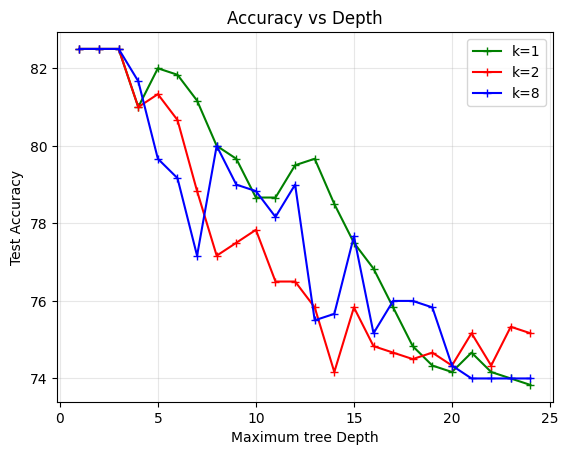

In [77]:
ks = [1,2,8]
acc_1, acc_2, acc_8 = [],[],[]
depths = list(range(1,25))

for k in ks:
  pca = PCA(n_components=k)
  X_train_pca = pca.fit_transform(scaled_data)
  X_test_pca = pca.transform(scaled_test)
  for depth in range(1,25):
    classifier = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    classifier.fit(X_train_pca, y_train)
    acc = classifier.score(X_test_pca, y_test)
    if k == 1:
      acc_1.append(acc*100)
    elif k == 2:
      acc_2.append(acc*100)
    else:
      acc_8.append(acc*100)

plt.plot(depths, acc_1, "g+-", label = f"k=1")
plt.plot(depths, acc_2, "r+-", label = f"k=2")
plt.plot(depths, acc_8, "b+-", label = f"k=8")


plt.xlabel("Maximum tree Depth")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs Depth")

plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.show()

e) PC1 mostly maintains best performance accross depeths, showing better performance at deeper depths compared to PC2 and PC8 since PC1 captures the highest variance and discards most of the noise from the remaining components. The tree has only one axis to split on and hence it cannot overfit as aggressively as others. Whereas PC2 captures


 At shallow depths, all 3 perform similarlydepThe plot suggests that PCA1 preserves majority of meaningful variance, mostly maintatining best accuracy until epoch ~18. whereas PCA2 and PCA8 trades places for 2nd best accuracy

# **Q3**

a)

In [78]:
!pip -q install --upgrade "scipy==1.16.3" "gensim==4.4.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 42.0 MB/s eta 0:00:00


In [80]:
import gensim.downloader as api
import urllib.request
import nltk
from nltk.tokenize import word_tokenize

nltk.download("punkt")
nltk.download("punkt_tab")

#Loading model
model_name = "glove-wiki-gigaword-100"
model = api.load(model_name)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


KeyboardInterrupt: 

In [ ]:
import pandas as pd

source_corpus_url = "https://www.gutenberg.org/cache/epub/1342/pg1342.txt"
with urllib.request.urlopen(source_corpus_url) as f:
  text = f.read().decode("utf-8")

# corpus = list(set(word for word in word_tokenize(text.lower()) if word.isalpha()))
corpus = list(set(word_tokenize(text.lower())))
print(len(corpus))
# print(corpus[:20])

words = ["good", "bad", "happy", "sad", "angry"]
closest = {}

for word in words:
  closest_sentiments = []
  closest_words = model.most_similar(word, topn=300)
  for word_, score in closest_words:
    if word_ in corpus:
      closest_sentiments.append((word_,score))
    # print(f"{word}: {score}")
  closest[word] = closest_sentiments[:3]
  print(f"\n 3 closest words to {word} in corpus are: {closest[word]}\n")



8037

 3 closest words to good in corpus are: [('better', 0.893191397190094), ('sure', 0.8314563035964966), ('really', 0.8297762274742126)]


 3 closest words to bad in corpus are: [('worse', 0.7929712533950806), ('good', 0.7702797651290894), ('things', 0.7653602957725525)]


 3 closest words to happy in corpus are: [('feel', 0.8132575750350952), ('i', 0.7938276529312134), ('really', 0.7903971076011658)]


 3 closest words to sad in corpus are: [('sorry', 0.7547181248664856), ('awful', 0.7284238934516907), ('horrible', 0.7049302458763123)]


 3 closest words to angry in corpus are: [('enraged', 0.7717769145965576), ('frightened', 0.711874783039093), ('shocked', 0.69240403175354)]



In [ ]:
df = pd.DataFrame.from_dict({
    word:[f"{word_} ({score})" for word_,score in scores] for word, scores in closest.items()})

df = df.style.set_table_styles([
    {"selector": "th", "props": [("text-align", "center"), ("padding-left", "20px"), ("padding-right", "20px")]},
    {"selector": "td", "props": [("text-align", "left"),("padding-left", "20px"), ("padding-right", "20px")]}
])
df

,good,bad,happy,sad,angry
0,better (0.893191397190094),worse (0.7929712533950806),feel (0.8132575750350952),sorry (0.7547181248664856),enraged (0.7717769145965576)
1,sure (0.8314563035964966),good (0.7702797651290894),i (0.7938276529312134),awful (0.7284238934516907),frightened (0.711874783039093)
2,really (0.8297762274742126),things (0.7653602957725525),really (0.7903971076011658),horrible (0.7049302458763123),shocked (0.69240403175354)


b)

The neighbours for "sad" and "angry" most clearly reflect sentiment similarity,  "sorry", "awful", "horrible" are genuinely negative emotional words, and "enraged", "frightened", "shocked" are all strong emotional states.
However, many other neighbours reflect contextual patterns rather than true sentiment. For "good", "sure" and "really" are not semantically similar words but are syntactic occurrences ("really good", "I'm sure it's good"). Similarly, "happy" returning "feel" and "i" reflects the frequent pattern "I feel happy" in the text rather than any sentimental similarity.


c)

The surprising one seems to be "bad" retrieving "good" as its second-closest neighbour. These are antonyms, yet they appear close in embedding space. It might be because they appear in identical syntactical contexts in the text like "it was good/bad", "good and bad".

d)

# Q4)

a)

A Multi Layer Perceptron(MLP) was chosen as the network architecture, consisting of 5 hidden layers with dimensions 6->64->128->256->128->64->1. The MLP is appropriate in this regression task since the dataset is a 6 dimension tabular feature vector. GELU activation function was used for all hidden layers, since this function has a smooth curve, thereby reducing the risk of inactive neurons compared to ReLU during training showed better generalisation. Mean Absolute Error(MAE) loss function was used for training and validation as the testing is to be done using MAE. Adam optimizer was used with a learning rate of 0.0001, as its less sesnsitive to hyperparameters and shows faster convergence for this regression task.

The target variable and two input features(cross_sectional_area_m2 and satellite_mass_kg) were skewed and were log transformed before scaling the data using StandardScaler, this heavily improves gradient stability and faster convergence.

In [31]:
from predict_decay import DecayPredictionNetwork, OrbitalDataset
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np
from matplotlib import pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device:", device)

dataset = 'orbital_decay.csv'
df = pd.read_csv(dataset)

X = df.drop(columns=['decay_time_days']).values # remove target variable from features
y = df['decay_time_days'].values # target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_train = np.log1p(y_train) #log-transform target variable to reduce skewness and make it easier for model to learn patterns
y_test = np.log1p(y_test)

#2 of these columns are also skewed
X_train[:, 1] = np.log1p(X_train[:, 1])  # satellite_mass_kg
X_train[:, 2] = np.log1p(X_train[:, 2])  # cross_sectional_area_m2
X_test[:, 1]  = np.log1p(X_test[:, 1])
X_test[:, 2]  = np.log1p(X_test[:, 2])


scaler_x = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_x.fit_transform(X_train)
X_test = scaler_x.transform(X_test)

y_train = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten() # Reshape y_train to 2D for scaling and flatten back to 1D
y_test = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

train_data = OrbitalDataset(X_train, y_train,)
test_data = OrbitalDataset(X_test, y_test) # Pass scalers from training dataset to ensure same scaling

train_loader = DataLoader(train_data, batch_size=128, shuffle=True, num_workers=0)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False, num_workers=0)

#Initialise model
model = DecayPredictionNetwork()
model.to(device)

#Training
epochs= 3000
# loss_fn = nn.MSELoss()
MAE_loss = nn.L1Loss()
opt = optim.Adam(model.parameters(), lr=0.0001)

# print(scaler_x.mean_)
# print(scaler_x.scale_)
# print(scaler_y.mean_)
# print(scaler_y.scale_)

training_losses = []
testing_losses = []

for epoch in range(epochs):
    model.train()
    total_loss=0
    for x, y in train_loader:
        # Move batch to same device as model
        x, y = x.to(device), y.to(device)
        # Forward pass
        pred_decay_times = model(x)
        # Compute loss
        loss = MAE_loss(pred_decay_times, y)

        # Backward pass and optimization
        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += loss.item() * x.size(0) # Accumulate loss weighted by batch size

    training_losses.append(total_loss/len(train_data))

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            output = model(x)
            loss_ = MAE_loss(output, y).item() * x.size(0)
            val_loss += loss_
    testing_losses.append(val_loss/len(test_data))
    # scheduler.step()
    print(f'Epoch {epoch} |Train loss: {training_losses[-1]:.4f} | Val loss: {testing_losses[-1]:.4f}')


# plt.title("Training curve")
# plt.plot(range(len(training_losses)),training_losses,'r')
# plt.plot(range(len(testing_losses)),testing_losses,'g')
# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# filename = f'training_curve.png'
# plt.savefig(filename)
# plt.show()
# plt.clf() # Clear the figure for the next plot

torch.save(model.state_dict(), 'weights_decay.pth') #save nn weights

using device: cuda
Epoch 0 |Train loss: 0.8103 | Val loss: 0.8758
Epoch 1 |Train loss: 0.8064 | Val loss: 0.8709
Epoch 2 |Train loss: 0.8000 | Val loss: 0.8619
Epoch 3 |Train loss: 0.7873 | Val loss: 0.8441
Epoch 4 |Train loss: 0.7622 | Val loss: 0.8082
Epoch 5 |Train loss: 0.7141 | Val loss: 0.7409
Epoch 6 |Train loss: 0.6318 | Val loss: 0.6328
Epoch 7 |Train loss: 0.5342 | Val loss: 0.5174
Epoch 8 |Train loss: 0.4754 | Val loss: 0.4496
Epoch 9 |Train loss: 0.4316 | Val loss: 0.4124
Epoch 10 |Train loss: 0.3925 | Val loss: 0.3758
Epoch 11 |Train loss: 0.3609 | Val loss: 0.3455
Epoch 12 |Train loss: 0.3375 | Val loss: 0.3263
Epoch 13 |Train loss: 0.3204 | Val loss: 0.3149
Epoch 14 |Train loss: 0.3087 | Val loss: 0.3061
Epoch 15 |Train loss: 0.2985 | Val loss: 0.3000
Epoch 16 |Train loss: 0.2885 | Val loss: 0.2911
Epoch 17 |Train loss: 0.2794 | Val loss: 0.2832
Epoch 18 |Train loss: 0.2699 | Val loss: 0.2750
Epoch 19 |Train loss: 0.2602 | Val loss: 0.2672
Epoch 20 |Train loss: 0.2511 | 

# Q)5

a)

The network is a custom convolutional neural network(CNN) consisiting of four convolutional blocks followed by fully conncted layer and the final classifier head after flattening the image. Each convolutional layer is followed by Batch Normalisation, ReLU activation and MaxPooling with kernal size 2. The channel dimension increases progressively: 3->32->64->128->256, and each MaxPool halves the spatial dimensions over the forward pass, input reduces from 128x128 down to 8x8 after all four layers. The output is then flattened and passed through two fully connected layers with BatchNorm and ReLU before the final layer, producing logits over 16 classes(256x8x8 -> 128 -> num_classes(16)).

Classification was chosen over regression since the products of each of three dice faces belongs to a fixed set of 16 unique values. Different configuration of convolutional layers were tested, ultimately 4 layers gave the best performance, learning more discriminative patterns. BatchNormalisation used after each layer stabilises training and also provides some regularisation.

Adam Optimizer was used over SGD because its less sensitivite to hyperparamter tuning and typically shows faster convergence.A learning rate of 0.00001 and weight decay of 0.0001 were used to ensure stable training. Cross-Entropy loss was used over MSE as it provides more stronger, informative gradients for classification tasks, leading to better optimisation performance.

In [71]:
from predict_product import DiceDataset, DiceNN
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
import pandas as pd
import math
from matplotlib import pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("using device:", device)

dataset = '/content/dice_images/train/images'
labels_csv = '/content/dice_images/train/labels.csv'

labels_df = pd.read_csv(labels_csv)


#Transforms
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomCrop((128,128), padding=4),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.0764, 0.1152, 0.3394], std=[1.4133, 1.4786, 1.4816])
])
val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.0764, 0.1152, 0.3394], std=[1.4133, 1.4786, 1.4816])
])

train_df, val_df = train_test_split(labels_df, test_size=0.2, random_state=42)

train_data = DiceDataset(image_file=dataset, df= train_df, transform=train_transforms, train=True)
val_data = DiceDataset(image_file=dataset, df= val_df, transform=val_transforms, train=False)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True, num_workers=0)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False, num_workers=0)

#calculate mean and std for normalization
# mean,std = 0.0,0.0
# for imgs,_ in train_loader:
#     mean += imgs.mean([0,2,3])
#     std += imgs.std([0,2,3])
# mean /= len(train_loader)
# std /= len(train_loader)
# print(mean,std)
# output = tensor([0.0764, 0.1152, 0.3394]) tensor([1.4133, 1.4786, 1.4816])

#Initialise model
model = DiceNN(NUM_CLASSES)
model.to(device)

#Training
epochs=300
loss_fn = nn.CrossEntropyLoss()
opt = optim.Adam(model.parameters(), lr=0.00001, weight_decay=1e-4)

training_losses = []
training_accuracies = []
testing_losses = []
testing_accuracies = []
steps_per_epoch = math.ceil(len(train_data) / train_loader.batch_size)
for epoch in range(epochs):
    correct = 0
    total = 0
    total_loss = 0
    model.train()
    for step, (imgs, labels) in enumerate(train_loader):
        imgs, labels = imgs.to(device), labels.to(device)
        pred_product = model(imgs)
        loss = loss_fn(pred_product, labels)
        # Backward pass and optimization
        opt.zero_grad()
        loss.backward()
        opt.step()

        total_loss += loss.item() * imgs.size(0) # Accumulate loss weighted by batch size
        correct += (pred_product.argmax(dim=1) == labels).sum().item() # Count correct predictions
        total += float(labels.size(0)) # Count total samples

        if step % 40 == 0: # Print loss every 40 steps
            print(f'epoch:{epoch},step:{step},loss:{loss.item():.3f}')

    train_accuracy = correct / total
    total_loss /= len(train_data) # Average loss over epoch
    training_losses.append(total_loss)
    training_accuracies.append(train_accuracy)
    print('Train accuracy over epoch {}: {:.4f}'.format(epoch+1,training_accuracies[-1]))

    val_correct = 0
    val_total = 0
    val_total_loss = 0
    model.eval()
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            output = model(imgs)
            loss = loss_fn(output, labels)
            pred_y = torch.argmax(output, dim=1)
            val_correct += (pred_y == labels).sum()
            val_total   += labels.size(0)
            val_total_loss += loss.item() * imgs.size(0)
        test_accuracy = val_correct / val_total
    val_total_loss /= len(val_data)
    testing_losses.append(val_total_loss)
    testing_accuracies.append(test_accuracy.cpu())
    print(f'Epoch {epoch} | Train acc: {100*correct/total:.1f}% | Val acc: {100*val_correct/val_total:.1f}%')

torch.save(model.state_dict(), 'weights_product.pth') #save nn weights

plt.title("Training curve")
plt.plot(range(len(training_losses)),training_losses,'r')
plt.plot(range(len(testing_losses)),testing_losses,'g')
plt.xlabel("Epoch")
plt.ylabel("Loss")
filename = f'training_curve_epo{epoch}.png'
plt.savefig(filename)
# plt.show()
plt.clf() # Clear the figure for the next plot

plt.title("Classification accuracy")
plt.plot(range(len(training_accuracies)),training_accuracies,'r')
plt.plot(range(len(testing_accuracies)),testing_accuracies,'g')
plt.yticks ([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
plt.xlabel("Epoch")
plt.ylabel("Classification accuracy")
filename = f'accuracy_curve_epo{epoch}.png'
plt.savefig(filename)

# plt.show()




using device: cuda
epoch:0,step:0,loss:2.921
epoch:0,step:40,loss:2.602
Train accuracy over epoch 1: 0.1256
Epoch 0 | Train acc: 12.6% | Val acc: 14.5%
epoch:1,step:0,loss:2.493
epoch:1,step:40,loss:2.397
Train accuracy over epoch 2: 0.2465
Epoch 1 | Train acc: 24.6% | Val acc: 27.5%
epoch:2,step:0,loss:2.339
epoch:2,step:40,loss:2.274
Train accuracy over epoch 3: 0.3119
Epoch 2 | Train acc: 31.2% | Val acc: 30.7%
epoch:3,step:0,loss:2.257
epoch:3,step:40,loss:2.100
Train accuracy over epoch 4: 0.3277
Epoch 3 | Train acc: 32.8% | Val acc: 33.4%
epoch:4,step:0,loss:2.103
epoch:4,step:40,loss:2.011
Train accuracy over epoch 5: 0.3560
Epoch 4 | Train acc: 35.6% | Val acc: 34.6%
epoch:5,step:0,loss:2.177
epoch:5,step:40,loss:2.062
Train accuracy over epoch 6: 0.3699
Epoch 5 | Train acc: 37.0% | Val acc: 36.8%
epoch:6,step:0,loss:2.044
epoch:6,step:40,loss:2.033
Train accuracy over epoch 7: 0.3839
Epoch 6 | Train acc: 38.4% | Val acc: 38.6%
epoch:7,step:0,loss:1.988
epoch:7,step:40,loss:2.0

KeyboardInterrupt: 